# Evaluation of CelebA Selectors (Aggregators)

This notebook generates counterfactuals for the CelebA dataset in latent space using an ensemble of explainers, evaluates them using standardized metrics, and compares the behavior and overlap of different selection strategies (Pareto, IdealPoint, TOPSIS, etc.).

In [ ]:
import os
import torch
import torch.nn as nn
import pickle
import numpy as np
import pandas as pd
import sys
import kagglehub
import itertools
from PIL import Image
from torch.utils.data import DataLoader
import torchvision.transforms as T
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../src'))
from explainers_lib.counterfactual import Counterfactual
from explainers_lib.aggregators import Pareto, IdealPoint, BalancedPoint, TOPSIS, DensityBased, All
from explainers_lib.datasets import Dataset as ExplainersDataset
from explainers_lib.model import TorchModel
from explainers_lib.ensemble import Ensemble, cfs_group_by_original_data
from explainers_lib.utils.scores import get_scores

from explainers_lib.explainers.native.face import FaceExplainer
from explainers_lib.explainers.native.wachter import WachterExplainer
from explainers_lib.explainers.native.growing_spheres import GrowingSpheresExplainer
from explainers_lib.explainers.celery_explainer import AlibiCFProto, AlibiCFRLCelebA, DiceExplainer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


/home/berni/education/counterfactuals/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 1. Model Definitions and Weight Loading

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_c), nn.LeakyReLU(0.2)
        )
    def forward(self, x): return self.block(x)

class TransConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_c), nn.LeakyReLU(0.2)
        )
    def forward(self, x): return self.block(x)

class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(3, 32), ConvBlock(32, 64), ConvBlock(64, 128),
            ConvBlock(128, 256), ConvBlock(256, 512), ConvBlock(512, 512),
            nn.Flatten(), nn.Linear(512 * 2 * 2, latent_dim), nn.Tanh()
        )
    def forward(self, x): return self.encoder(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(latent_dim, 512 * 2 * 2), nn.Tanh())
        self.decoder = nn.Sequential(
            TransConvBlock(512, 512), TransConvBlock(512, 512),
            TransConvBlock(512, 256), TransConvBlock(256, 128),
            TransConvBlock(128, 64), TransConvBlock(64, 32),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=1, padding=1), nn.Tanh()
        )
    def forward(self, z):
        x = self.fc(z).view(-1, 512, 2, 2)
        return self.decoder(x)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.3),
            nn.Conv2d(64, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.3)
        )
        flatten_dim = 32 * 32 * 32
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(flatten_dim, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, 2)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class LatentToClassPipeline(nn.Module):
    __annotations__ = {}
    def __init__(self, decoder, cnn):
        super().__init__()
        self.decoder = decoder
        self.cnn = cnn
    def forward(self, x):
        decoded = self.decoder(x) * 0.5
        return self.cnn(decoded)

encoder = Encoder(latent_dim=128).to(device)
decoder = Decoder(latent_dim=128).to(device)
weights = torch.load('autoencoder_celeba_best.pth', map_location=device)
encoder.load_state_dict({k[len('encoder.'):]: v for k, v in weights.items() if k.startswith('encoder.')})
decoder.load_state_dict({k[len('decoder.'):]: v for k, v in weights.items() if k.startswith('decoder.')})
encoder.eval(); decoder.eval()

cnn = CNN()

cnn_weights = torch.load('models/torch_cnn_celeba_paper_smile_only.pth', map_location=device)

target_indices = [0, 1]

cnn_weights['classifier.4.weight'] = cnn_weights['classifier.4.weight'][target_indices]
cnn_weights['classifier.4.bias'] = cnn_weights['classifier.4.bias'][target_indices]

cnn.load_state_dict(cnn_weights)
cnn.to(device).eval()

pipeline = LatentToClassPipeline(decoder, cnn).to(device)
scripted_pipeline = torch.jit.script(pipeline.to("cpu"))
model = TorchModel(scripted_pipeline)


## 2. Data Preparation

In [5]:
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
img_dir = os.path.join(path, "img_align_celeba/img_align_celeba")
attr_path = os.path.join(path, "list_attr_celeba.csv")

df = pd.read_csv(attr_path)
df = df.rename(columns=lambda s: s.strip())
df["class"]  = df["Smiling"].apply(lambda x: 1 if x == 1 else 0)

train_df, test_df = train_test_split(df, test_size=1000, shuffle=True, random_state=42)
transform = T.Compose([T.Resize((128, 128)), T.ToTensor(), T.Normalize((0.5,)*3, (0.5,)*3)])

class Celeb4ClassDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df, self.img_dir, self.transform = dataframe, img_dir, transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row["image_id"])).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, torch.tensor(row["class"], dtype=torch.long)

train_dl = DataLoader(Celeb4ClassDataset(train_df, img_dir, transform), batch_size=64, shuffle=True)
test_dl = DataLoader(Celeb4ClassDataset(test_df, img_dir, transform), batch_size=32, shuffle=False)


## 3. Latent Space Conversion

In [6]:
def get_latent_dataset(dataloader, n_samples=5000):
    latent_list, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in dataloader:
            latent = encoder(imgs.to(device)).cpu().numpy()
            latent_list.append(latent)
            labels_list.append(labels.numpy())
            if len(np.concatenate(latent_list)) >= n_samples: break
    
    X = np.concatenate(latent_list)[:n_samples]
    y = np.concatenate(labels_list)[:n_samples]
    feature_names = [f'l{i}' for i in range(128)]
    df_latent = pd.DataFrame(X, columns=feature_names)
    
    identity = ColumnTransformer([('num', 'passthrough', feature_names)], remainder='drop')
    identity.fit(df_latent)
    
    return ExplainersDataset(df_latent, y, features=feature_names, 
                             continuous_features=feature_names, preprocessor=identity)

latent_train_ds = get_latent_dataset(train_dl, n_samples=50)
latent_test_ds = get_latent_dataset(test_dl, n_samples=5)


## 4. Counterfactual Generation

In [7]:

ensemble = Ensemble(model, [
    WachterExplainer(lambda_param=500),
    GrowingSpheresExplainer(step_size=0.01, num_samples=5, max_radius=5),
    FaceExplainer(),
    AlibiCFProto(),
    DiceExplainer()
], All())

print(latent_train_ds.data.shape)

ensemble.fit(latent_train_ds)
print("Generating counterfactuals...")
all_generated_cfes = ensemble.explain(latent_test_ds)


(50, 128)
Generating counterfactuals...


100%|██████████| 5/5 [00:39<00:00,  7.98s/instance]
5instance [10:22, 124.43s/instance]
100%|██████████| 5/5 [00:00<00:00, 287.01instance/s]


## 5. Score Evaluation and Selector Comparison

,Proximity,Feasibility,K_Feasibility(3),FeaturesChanged,DiscriminativePower(9)
IdealPoint,7.582562,20.235310,24.192673,0.367188,0.422222
BalancedPoint,10.545872,20.795533,24.815631,0.717187,0.555556
TOPSIS,5.865000,24.358894,26.310760,0.370312,0.511111
DensityBased,16.028655,35.984570,36.963285,0.796875,0.466667


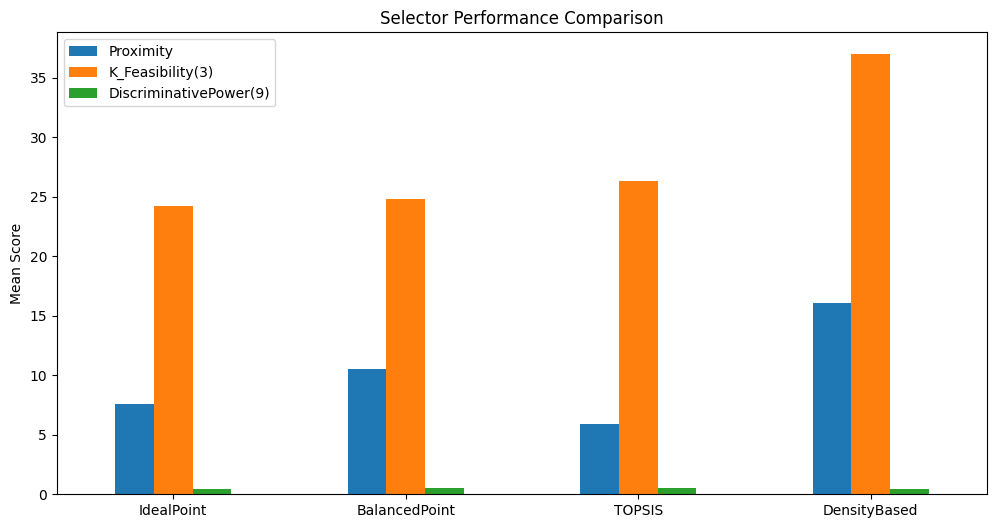

In [8]:
selectors = {
    # "Pareto": Pareto(),
    "IdealPoint": IdealPoint(),
    "BalancedPoint": BalancedPoint(),
    "TOPSIS": TOPSIS(k=1),
    "DensityBased": DensityBased(k=1)
}

for name, s in selectors.items():
    s.fit(model, latent_train_ds)

results_by_selector = {name: [] for name in selectors}
grouped_cfs = cfs_group_by_original_data(all_generated_cfes)

for original_idx, cfs in grouped_cfs.items():
    for name, selector in selectors.items():
        selected = selector(cfs, include_scores=True)
        results_by_selector[name].extend(selected)

selector_means = {}
for name, selected_list in results_by_selector.items():
    scores = [cf.metadata['scores'] for cf in selected_list if 'scores' in cf.metadata]
    if scores: selector_means[name] = pd.DataFrame(scores).mean()

comparison_df = pd.DataFrame(selector_means).T
display(comparison_df)

metrics = ["Proximity", "K_Feasibility(3)", "DiscriminativePower(9)"]
comparison_df[metrics].plot(kind="bar", figsize=(12, 6), title="Selector Performance Comparison")
plt.ylabel("Mean Score")
plt.xticks(rotation=0)
plt.show()


## 6. Selector Overlap Analysis

Counterfactual Selections (Explainer source):


,Instance,BalancedPoint,DensityBased,IdealPoint,TOPSIS
0,0,cfproto(),"wachter(lambda_param=500, method=COBYLA, max_i...","dice_explainer(num_cfs=1, method='random')","dice_explainer(num_cfs=1, method='random')"
1,1,cfproto(),"dice_explainer(num_cfs=1, method='random')",cfproto(),cfproto()
2,2,"wachter(lambda_param=500, method=COBYLA, max_i...","growing_spheres(step_size=0.01, max_radius=5, ...",cfproto(),"dice_explainer(num_cfs=1, method='random')"
3,3,cfproto(),"wachter(lambda_param=500, method=COBYLA, max_i...",cfproto(),cfproto()
4,4,"wachter(lambda_param=500, method=COBYLA, max_i...","growing_spheres(step_size=0.01, max_radius=5, ...",cfproto(),"wachter(lambda_param=500, method=COBYLA, max_i..."


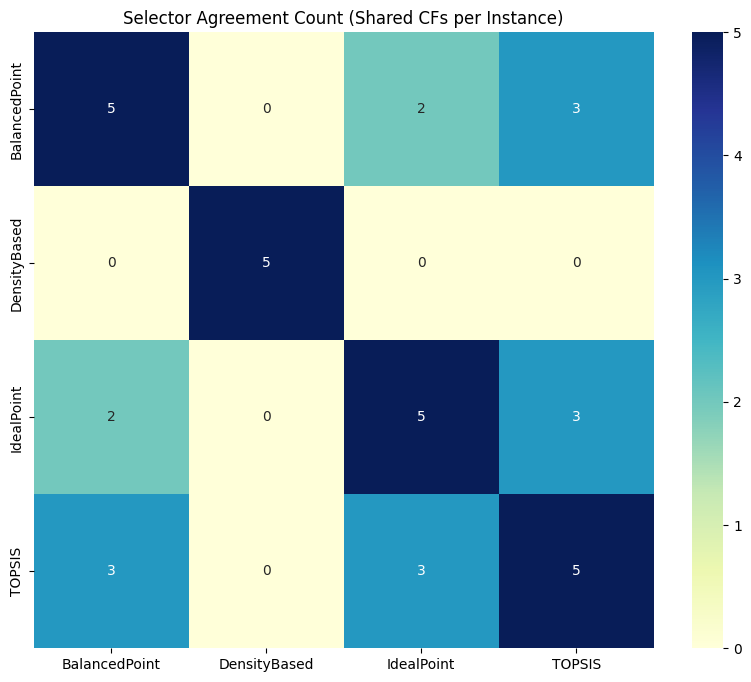

In [ ]:
instance_keys = list(grouped_cfs.keys())
names = sorted(selectors.keys())
agreement_matrix = pd.DataFrame(0, index=names, columns=names)

selections_data = []

for i, key in enumerate(instance_keys):
    cfs = grouped_cfs[key]
    selected_for_instance = {}
    
    for name, selector in selectors.items():
        selected = selector(cfs)
        if selected:
            selected_for_instance[name] = selected[0]
        else:
            selected_for_instance[name] = None
            
    row = {"Instance": i}
    for name in names:
        cf = selected_for_instance[name]
        row[name] = f"{cf.explainer}" if cf else "None"
    selections_data.append(row)
    
    for s1 in names:
        for s2 in names:
            if selected_for_instance[s1] is not None and selected_for_instance[s2] is not None:
                if selected_for_instance[s1] is selected_for_instance[s2]:
                    agreement_matrix.loc[s1, s2] += 1

print("Counterfactual Selections (Explainer source):")
display(pd.DataFrame(selections_data))

plt.figure(figsize=(10, 8))
sns.heatmap(agreement_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Selector Agreement Count (Shared CFs per Instance)")
plt.show()


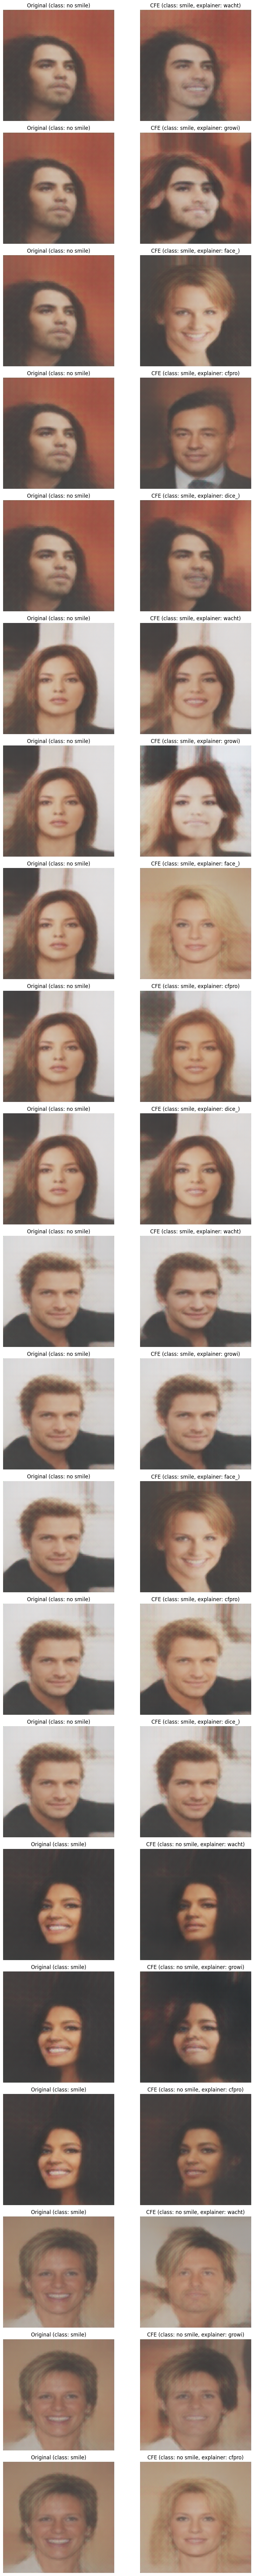

In [10]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(0.2)
        )
    def forward(self, x):
        return self.block(x)

class TransConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(0.2)
        )
    def forward(self, x):
        return self.block(x)

class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(3,   32),   # 128 -> 64
            ConvBlock(32,  64),   # 64 -> 32
            ConvBlock(64,  128),  # 32 -> 16
            ConvBlock(128, 256),  # 16 -> 8
            ConvBlock(256, 512),  # 8 W-> 4
            ConvBlock(512, 512),  # 4 -> 2
            nn.Flatten(),
            nn.Linear(512 * 2 * 2, latent_dim),
            nn.Tanh()
        )

    def forward(self, x):
        return self.encoder(x)
    
class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 512 * 2 * 2),
            nn.Tanh()
        )

        self.decoder = nn.Sequential(
            TransConvBlock(512, 512),   # 2 → 4
            TransConvBlock(512, 512),   # 4 → 8
            TransConvBlock(512, 256),   # 8 → 16
            TransConvBlock(256, 128),   # 16 → 32
            TransConvBlock(128, 64),    # 32 → 64
            TransConvBlock(64, 32),     # 64 → 128
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 512, 2, 2)
        x = self.decoder(x)
        return x
    
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim).to(device)
        self.decoder = Decoder(latent_dim).to(device)

    def forward(self, x):
        return self.decoder(self.encoder(x))


autoencoder = Autoencoder(latent_dim=128).to(device)

weights = torch.load("autoencoder_celeba_best.pth", map_location=device)

autoencoder.load_state_dict(weights)

autoencoder.eval()

class_map = {
    0: "no smile",
    1: "smile",
}


n = len(all_generated_cfes)
plt.figure(figsize=(10, 4 * n))
autoencoder.to(device)
autoencoder.eval()

for i in range(n):
    cf = all_generated_cfes[i]

    # ---- ORIGINAL RECONSTRUCTION ----
    org_latent = torch.tensor(cf.original_data, dtype=torch.float32, device=device).unsqueeze(0)
    org_recon = autoencoder.decoder(org_latent)      # shape [1, 3, 128, 128]

    org_recon_np = org_recon.detach().cpu().permute(0, 2, 3, 1).numpy()[0]

    # map from [-1, 1] → [0, 1]
    org_recon_np = (org_recon_np + 1) / 2
    org_recon_np = org_recon_np.clip(0, 1)

    # ---- COUNTERFACTUAL RECONSTRUCTION ----
    cf_latent = torch.tensor(cf.data, dtype=torch.float32, device=device).unsqueeze(0)
    cfe_recon = autoencoder.decoder(cf_latent)

    cfe_recon_np = cfe_recon.detach().cpu().permute(0, 2, 3, 1).numpy()[0]
    cfe_recon_np = (cfe_recon_np + 1) / 2
    cfe_recon_np = cfe_recon_np.clip(0, 1)

    # ---- PLOTTING ----
    plt.subplot(n, 2, 2 * i + 1)
    plt.imshow(org_recon_np)
    plt.title(f"Original (class: {class_map[cf.original_class]})")
    plt.axis("off")

    plt.subplot(n, 2, 2 * i + 2)
    plt.imshow(cfe_recon_np)
    plt.title(f"CFE (class: {class_map[cf.target_class]}, explainer: {cf.explainer[:5]})")
    plt.axis("off")

plt.tight_layout()
plt.show()
